# Integración Numérica
**Módulo 5 — Integración de Monte Carlo**

**Programación Científica 2026-1 · Universidad Nacional de Colombia**
mbastidaso@unal.edu.co


[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/)
---

En este notebook pondremos en práctica el método de **Monte Carlo** para resolver problemas de integración numérica que sufren de la *maldición de la dimensionalidad*. La idea principal es utilizar la aleatoriedad ("tirar dardos") para estimar proporciones geométricas y calcular áreas o volúmenes.

## 0. Configuración de estilo

In [1]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 14,
    # Ejes y Ticks
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.direction": "in",
    "ytick.direction": "in",
    # Grid
    "grid.color"    : "gray",
    "grid.linewidth": 0.3,
    "grid.alpha"    : 0.3,
    "grid.linestyle": "--",
    # Estética
    "figure.dpi"        : 120,
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
})

print('Configuración OK')

Configuración OK


---
## 1. Estimación de $\pi$ mediante "Dardos" (2 Dimensiones)

Imagina un cuadrado de lado 2 centrado en el origen (área $= 4$). Dentro de él, hay un círculo de radio 1 (área $= \pi$).

Si lanzamos dardos de forma completamente aleatoria (con una distribución uniforme) sobre el cuadrado, la probabilidad $P$ de que un dardo caiga dentro del círculo es igual a la proporción de sus áreas:

$$P = \frac{\text{Área del Círculo}}{\text{Área del Cuadrado}} = \frac{\pi}{4}$$

Por lo tanto, si lanzamos $N$ dardos y contamos cuántos caen dentro del círculo ($N_{\text{dentro}}$), podemos estimar el valor de $\pi$:

$$\pi \approx 4 \times \frac{N_{\text{dentro}}}{N}$$

**Condición Lógica:**
Un punto de coordenadas $(x, y)$ pertenece al círculo (y al área de interés) si cumple la siguiente inecuación geométrica:
$$x^2 + y^2 \leq 1$$

/tmp/ipykernel_6752/453385361.py:9: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  coordinates = np.row_stack([x,y]).T


Número total de puntos: 1000
Puntos dentro del círculo: 773
Estimación de pi: 3.092000
Valor real de pi: 3.141593
Error absoluto:   0.049593
Error relativo:   1.578583%


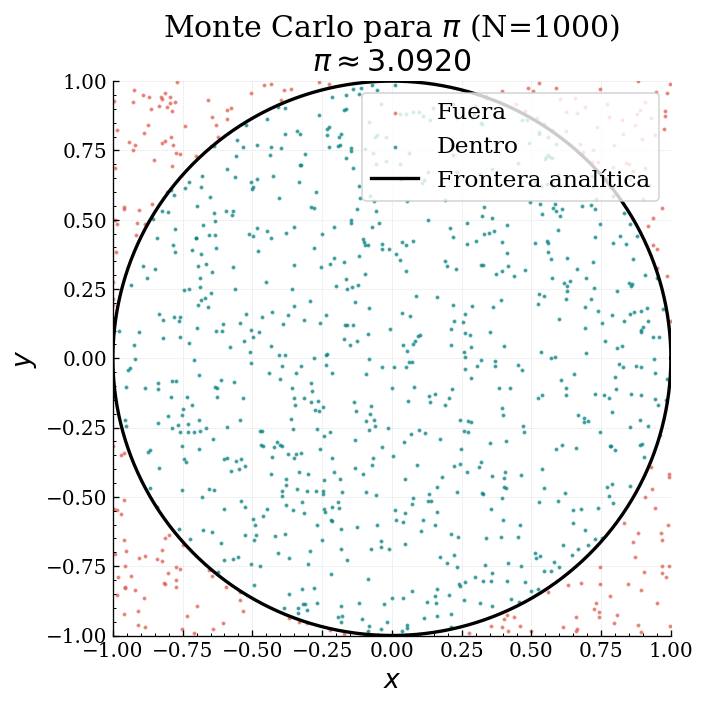

In [11]:
# 1. Parámetros
N = 1000  # Número total de dardos a lanzar

# 2. Generar coordenadas x e y aleatorias uniformes entre -1 y 1
x = np.random.uniform(-1, 1, N)
y = np.random.uniform(-1, 1, N)


coordinates = np.row_stack([x,y]).T

# 3. Evaluar la condición lógica
# 'adentro' es un arreglo booleano (True si el dardo está dentro, False si no)

def insideCircle(coord):
  x = coord[0]
  y = coord[1]
  if x**2 + y**2 <= 1:
    return True
  else:
    return False

adentro = []
N_dentro = 0
for coord in coordinates:
  adentro.append(insideCircle(coord))
  if insideCircle(coord):
    N_dentro += 1

adentro = np.array(adentro)
# 4. Calcular la estimación de pi
pi_estimado = 4 * N_dentro/N

print(f"Número total de puntos: {N}")
print(f"Puntos dentro del círculo: {N_dentro}")
print(f"Estimación de pi: {pi_estimado:.6f}")
print(f"Valor real de pi: {np.pi:.6f}")
print(f"Error absoluto:   {abs(pi_estimado - np.pi):.6f}")
print(f"Error relativo:   {abs(pi_estimado - np.pi)/np.pi*100:.6f}%")

# 5. Visualización del proceso
plt.figure(figsize=(6, 6))

# Dibujar puntos fuera del círculo (Rojo coral)
plt.scatter(x[~adentro], y[~adentro], color='#E05A4E', s=2, alpha=0.6, label='Fuera')

# Dibujar puntos dentro del círculo (Verde azulado - Teal)
plt.scatter(x[adentro], y[adentro], color='Teal', s=2, alpha=0.6, label='Dentro')

# Dibujar el contorno matemático del círculo exacto
theta = np.linspace(0, 2*np.pi, 200)
plt.plot(np.cos(theta), np.sin(theta), color='black', linewidth=2, label='Frontera analítica')

plt.xlim(-1, 1)
plt.ylim(-1, 1)
plt.title(f"Monte Carlo para $\\pi$ (N={N})\n$\\pi \\approx {pi_estimado:.4f}$")
plt.xlabel("$x$")
plt.ylabel("$y$")

plt.legend(loc="upper right")
plt.grid(True)
plt.show()

---
## 2. El Volumen de una Hiperesfera (10 Dimensiones)

En 2D, calcular el área nos pareció intuitivo. Pero, ¿qué pasa si queremos calcular el volumen de una esfera en **10 dimensiones**?

Si usamos un método numérico en malla estructurada (como la regla de Simpson o diferencias finitas) y colocamos **apenas 10 puntos por dimensión**, necesitaríamos evaluar la función $10^{10} = 10,000,000,000$ veces.  Esto es lo que se conoce formalmente como la **Maldición de la Dimensionalidad**.

¡**Monte Carlo** no sufre de esto! El algoritmo es exactamente el mismo, solo cambia la dimensión de los datos generados.

Encerramos la hiperesfera 10D en un hipercubo de lado 2.
- **Volumen del hipercubo contenedor:** $V_{\text{cubo}} = 2^{10} = 1024$.
- **Condición analítica para pertenecer a la hiperesfera:**
$$\sum_{i=1}^{10} x_i^2 \leq 1$$
- **Volumen estimado de la hiperesfera:**
$$V_{\text{esfera}} \approx 1024 \times \frac{N_{\text{dentro}}}{N}$$

### Ejercicio
Completa el código a continuación usando las herramientas vectorizadas de `numpy`.
*Pista: Al elevar al cuadrado la matriz de puntos, puedes usar `np.sum(..., axis=1)` para sumar las coordenadas de cada fila individualmente.*

In [ ]:
N = 10**6  # Un millón de dardos para buscar mayor precisión

# 1. Generamos N puntos, cada uno con 10 coordenadas independientes
# pts será una matriz gigante de dimensión (1.000.000, 10)
pts = np.random.uniform(-1, 1, (N, 10))

# --- TU TURNO ---
# 2. Calcula la suma de los cuadrados por cada fila (para cada punto)
sum_cuadrados = np.sum(pts**2,axis=1)

# 3. Encuentra cuántos puntos cumplen la condición (suma <= 1)
N_dentro_10D = np.where(a <=1,True,False)

# 4. Estima el volumen multiplicando la fracción por el volumen del hipercubo (1024)
# V_estimado = ...

# Evaluamos contra el valor matemático exacto
# El volumen exacto de una hiperesfera en 10D está dado analíticamente por (pi^5)/120
V_exacto = (np.pi**5) / 120

print(f"Puntos lanzados (N): {N}")
print(f"Puntos que cayeron dentro de la hiperesfera: {N_dentro_10D}")
print(f"Volumen estimado (Monte Carlo): {V_estimado:.5f}")
print(f"Volumen exacto analítico:       {V_exacto:.5f}")
print(f"Error absoluto:                 {abs(V_estimado - V_exacto):.5f}")
print(f"Error relativo:                 {abs(V_estimado - V_exacto)/V_exacto*100:.5f}%")

### Conclusión del Ejercicio
A nivel de programación, calcular una integral en **10 dimensiones** con este método requirió **exactamente el mismo esfuerzo y líneas de código** que hacerlo en 2 dimensiones gracias a la vectorización de `NumPy`.

Además, a pesar de que $10^6$ (un millón) parece un número grande de puntos, es una cantidad ridículamente pequeña comparada con los diez mil millones de evaluaciones que nos exigiría una malla tradicional (y eso para una resolución bajísima de 10 puntos por eje). Aún así, Monte Carlo logra entregarnos una excelente estimación del volumen.